# Lab 1 — Nivelación en Python y primera pirámide

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Semana 1: Nivelación Python y primera pirámide poblacional

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Este notebook acompaña las **notas de la semana 1** (secciones §3, §5 y §7) y la presentación de la semana.

**Objetivos:**
1. Verificar tu Python básico (listas, ciclos, funciones).
2. Conocer NumPy, pandas y matplotlib con datos poblacionales.
3. Construir tu primera **pirámide poblacional**.
4. Resolver en código la **pregunta 4 de la autoevaluación** (notas, §Autoevaluación).
5. Dejar lista la descarga de datos de **tu estado** (proyecto, notas §7).

**Reglas del lab:** trabaja las celdas marcadas `# TODO`. Documenta tus intentos en comentarios; las dudas se resuelven en clase o asesoría.

**Entrega:** sube este notebook ejecutado (Archivo → Descargar → .ipynb) en la página de la actividad, antes de la próxima clase. Tienes **dos intentos**: en el primero recibes orientación sin la solución, y puedes corregir.

In [21]:
# Configuración: ejecuta esta celda primero
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Listo: numpy', np.__version__, '| pandas', pd.__version__)

Listo: numpy 2.1.3 | pandas 2.2.3


## Parte 1 — Nivelación: Python básico

Nada demográfico todavía; solo verificamos herramientas. Si esta parte te cuesta, dedícale tiempo esta semana con McKinney caps. 2–4 (gratuito en línea).

In [22]:
# TODO 1.1: crea una lista con los años censales 1990, 1995, 2000, 2005, 2010, 2020
# y recórrela con un ciclo for imprimiendo cada año.

años_censales = [1990, 1995, 2000, 2005, 2010, 2020]

for año in años_censales:
    print(año)


# TODO 1.2: escribe una función crecimiento(N0, N1) que regrese el cambio
# porcentual entre dos poblaciones, y pruébala con N0=126.0, N1=127.2
# (el Ejemplo 1 de las notas, §3).

def crecimiento(N0, N1):
    return (N1 - N0) / N0 * 100

print()
print('Crecimiento de 126.0 a 127.2 millones:', round(crecimiento(126.0, 127.2), 4), '%')


1990
1995
2000
2005
2010
2020

Crecimiento de 126.0 a 127.2 millones: 0.9524 %


## Parte 2 — pandas con datos poblacionales

Usamos la población de **México por grupos quinquenales de edad y sexo** (cifras en miles, aproximadas al Censo 2020 con fines didácticos — en la Parte 5 usarás las cifras oficiales exactas de tu estado).

In [23]:
grupos = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
          '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80+']
hombres = [5104, 5449, 5535, 5455, 5301, 4919, 4443, 4110,
           3777, 3421, 2946, 2427, 1954, 1479, 1048,  678,  647]
mujeres = [4956, 5300, 5406, 5384, 5384, 5090, 4676, 4372,
           4082, 3728, 3250, 2712, 2201, 1684, 1211,  811,  874]

pob = pd.DataFrame({'grupo': grupos, 'hombres': hombres, 'mujeres': mujeres})
pob['total'] = pob['hombres'] + pob['mujeres']
pob

,grupo,hombres,mujeres,total
0,0-4,5104,4956,10060
1,5-9,5449,5300,10749
2,10-14,5535,5406,10941
3,15-19,5455,5384,10839
4,20-24,5301,5384,10685
5,25-29,4919,5090,10009
6,30-34,4443,4676,9119
7,35-39,4110,4372,8482
8,40-44,3777,4082,7859
9,45-49,3421,3728,7149


In [24]:
# TODO 2.1: calcula la población total del país (suma de la columna 'total') en miles y en millones.

total_miles = pob['total'].sum()
print(f'Población total: {total_miles:,.0f} miles = {total_miles/1000:,.2f} millones')


# TODO 2.2: ¿qué porcentaje de la población tiene menos de 15 años? (los primeros 3 grupos)
# Pista: pob.loc[0:2, 'total'].sum()

menores_15 = pob.loc[0:2, 'total'].sum()
print(f'Menores de 15 años: {menores_15:,.0f} miles '
      f'({menores_15 / total_miles * 100:.1f} % del total)')


# TODO 2.3: ¿en qué grupo de edad hay MÁS mujeres que hombres por primera vez?
# Explica en un comentario por qué crees que pasa (pista: notas §4, mortalidad).

mas_mujeres = pob[pob['mujeres'] > pob['hombres']]
print()
print('Grupos donde las mujeres superan a los hombres:')
print(mas_mujeres[['grupo', 'hombres', 'mujeres']].to_string(index=False))
print()
print('Primera vez en el grupo:', mas_mujeres.iloc[0]['grupo'])

# Razón de masculinidad (hombres por cada 100 mujeres)
pob['razon_masc'] = pob['hombres'] / pob['mujeres'] * 100
print()
print(pob[['grupo', 'razon_masc']].round(1).to_string(index=False))

# (2.3)
#Aunque, al nacer, la proporción es ligeramente mayor para los hombres, la mortalidad masculina es superior en
#todas las edades. En México, esta diferencia se dispara en las edades de adultos jóvenes debido a una mayor incidencia
#de causas de muerte violentas o accidentes. La emigración hacia el extranjero tiende a ser más alta en hombres en edad laboral, lo
#que acentúa la mayoría de mujeres a partir del grupo de 20-24 años.


Población total: 119,814 miles = 119.81 millones
Menores de 15 años: 31,750 miles (26.5 % del total)

Grupos donde las mujeres superan a los hombres:
grupo  hombres  mujeres
20-24     5301     5384
25-29     4919     5090
30-34     4443     4676
35-39     4110     4372
40-44     3777     4082
45-49     3421     3728
50-54     2946     3250
55-59     2427     2712
60-64     1954     2201
65-69     1479     1684
70-74     1048     1211
75-79      678      811
  80+      647      874

Primera vez en el grupo: 20-24

grupo  razon_masc
  0-4       103.0
  5-9       102.8
10-14       102.4
15-19       101.3
20-24        98.5
25-29        96.6
30-34        95.0
35-39        94.0
40-44        92.5
45-49        91.8
50-54        90.6
55-59        89.5
60-64        88.8
65-69        87.8
70-74        86.5
75-79        83.6
  80+        74.0


## Parte 3 — La pirámide poblacional

*\"La estructura por edad es la memoria del sistema\"* (notas §4). La pirámide es la forma estándar de visualizarla: barras horizontales, hombres a la izquierda (valores negativos), mujeres a la derecha.

/tmp/ipykernel_7436/4103702864.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(x)):,}' for x in ax.get_xticks()])


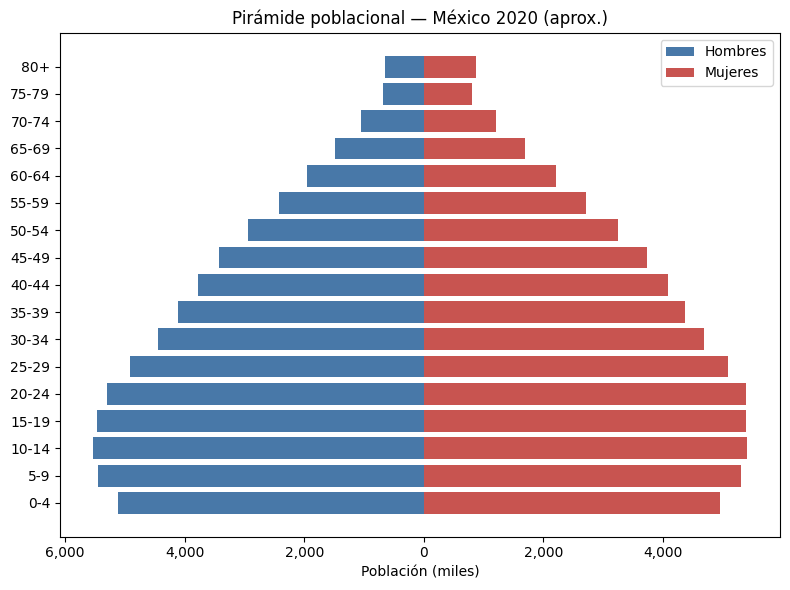

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(pob['grupo'], -pob['hombres'], color='#4878a8', label='Hombres')
ax.barh(pob['grupo'],  pob['mujeres'], color='#c85450', label='Mujeres')
ax.set_xlabel('Población (miles)')
ax.set_title('Pirámide poblacional — México 2020 (aprox.)')
ax.legend()
ax.set_xticklabels([f'{abs(int(x)):,}' for x in ax.get_xticks()])
plt.tight_layout()
plt.show()

In [26]:
# TODO 3.1: observa la pirámide y responde en este comentario:
#  (a) ¿La base (0-14) es más ancha o más angosta que el centro (15-39)? ¿Qué te dice eso
#      sobre la fecundidad reciente? (notas §4)
#  (b) ¿Dónde 'se lee' en la pirámide la mortalidad? ¿Y la migración podría verse? ¿Cómo?

base   = pob.loc[0:2,  'total'].sum()
centro = pob.loc[3:7,  'total'].sum()
cima   = pob.loc[13:,  'total'].sum()

print(f'0-14 : {base:>7,.0f} miles ({base/total_miles*100:4.1f} %) | promedio por grupo: {base/3:,.0f}')
print(f'15-39: {centro:>7,.0f} miles ({centro/total_miles*100:4.1f} %) | promedio por grupo: {centro/5:,.0f}')
print(f'65+  : {cima:>7,.0f} miles ({cima/total_miles*100:4.1f} %)')

# (3.1)
# (a) Aunque, en promedio, la base (0-14) parece más ancha, el primer escalón de 0-4 años (10,060 miles) es más
#angosto que el de 5-9 (10,749 miles). Esto dice que la fecundidad reciente ha comenzado a bajar en los últimos 5 años, haciendo que la
#pirámide pierda su forma triangular pura y empiece a "estrecharse" desde abajo.
# (b) La mortalidad se lee viendo cómo las barras se van acortando y adelgazando progresivamente conforme subimos a los grupos
#de mayor edad. La migración se puede ver como un abultamiento inusual o una mordida repentina en los bloques centrales
#de la pirámide, rompiendo la transición suave y afectando de manera asimétrica a hombres o mujeres.


0-14 :  31,750 miles (26.5 %) | promedio por grupo: 10,583
15-39:  49,134 miles (41.0 %) | promedio por grupo: 9,827
65+  :   8,432 miles ( 7.0 %)


## Parte 4 — La pregunta 4 de la autoevaluación, en código

De las notas (§3, Ejemplo 1 y §5): con $N(t)=126.0$ M, $B=2.0$ M, $D=0.75$ M, $I-E=-0.05$ M, calcula $TBN$, $TBM$, $r$ y el tiempo de duplicación $t_2 = \ln 2 / r$.

Usa como $\bar N$ (población a mitad de año) el promedio de $N(t)$ y $N(t+1)$.

In [27]:
N0 = 126.0   # millones
B  = 2.0
D  = 0.75
SM = -0.05   # saldo migratorio I - E

# TODO 4.1: calcula N1 con la ecuación compensadora (notas §3)
N1 = N0 + B - D + SM
print(f'4.1  N(t+1) = {N0} + {B} - {D} + ({SM}) = {N1:.2f} millones')

# TODO 4.2: calcula Nbar (promedio de N0 y N1), y con él TBN, TBM (por mil) y r
Nbar = (N0 + N1) / 2

TBN = B / Nbar * 1000
TBM = D / Nbar * 1000
TMN = SM / Nbar * 1000
r   = (B - D + SM) / Nbar

print(f'4.2  Nbar = {Nbar:.2f} millones')
print(f'     TBN  = {TBN:.2f} por mil')
print(f'     TBM  = {TBM:.2f} por mil')
print(f'     TMN  = {TMN:.2f} por mil')
print(f'     r    = {r:.6f} = {r*1000:.2f} por mil = {r*100:.3f} % anual')
print(f'     Comprobación: TBN - TBM + TMN = {TBN - TBM + TMN:.2f} por mil')

# TODO 4.3: calcula t2 = ln(2)/r con np.log(2). ¿Los años de duplicación te parecen
# realistas para México? ¿Qué supuesto fuerte estás haciendo? (notas §5)
t2 = np.log(2) / r
print(f'4.3  t2 = ln(2)/r = {np.log(2):.4f} / {r:.6f} = {t2:.1f} años')
print(f'La población se duplicaría hacia el año {2020 + t2:.0f} (si r no cambiara)')

# (4.3):
#No es realista pensar que la población se duplicará en 73.1 años. El cálculo viene de un modelo de crecimiento exponencial que asume que la
#tasa de crecimiento ($r$) se mantendrá constante a futuro.La tasa $r$ lleva décadas disminuyendo debido a la caída en la
#tasa de fecundidad, el envejecimiento poblacional y los saldos migratorios negativos. Es más probable que la población se estabilice antes de
#llegar a duplicarse.

# Cuando termines: anota tus valores de TBN, TBM, r y t2; los contrastaremos en clase.


4.1  N(t+1) = 126.0 + 2.0 - 0.75 + (-0.05) = 127.20 millones
4.2  Nbar = 126.60 millones
     TBN  = 15.80 por mil
     TBM  = 5.92 por mil
     TMN  = -0.39 por mil
     r    = 0.009479 = 9.48 por mil = 0.948 % anual
     Comprobación: TBN - TBM + TMN = 9.48 por mil
4.3  t2 = ln(2)/r = 0.6931 / 0.009479 = 73.1 años
La población se duplicaría hacia el año 2093 (si r no cambiara)


## Parte 5 — Tu estado (arranque del proyecto, notas §7)

Tu **entidad federativa** ya está asignada (la ves en la página de la actividad, y este notebook ya viene marcado con ella). Ahora consigue sus datos oficiales:

1. Entra a las **Proyecciones de la Población de México y de las Entidades Federativas** de CONAPO (datos.gob.mx o conapo.gob.mx) y descarga la población a mitad de año por edad y sexo de tu entidad, **o** al Censo 2020 de INEGI (Tabulados → Población).
2. Súbelo a Colab (ícono de carpeta → subir) y cárgalo con `pd.read_csv(...)` o `pd.read_excel(...)`.
3. Reproduce la pirámide de la Parte 3 **para tu estado**, con título y fuente citada.

*Si el archivo de CONAPO te da problemas de codificación, prueba `encoding='latin-1'` — y si te atoras más de 15 minutos, anótalo y lo resolvemos en clase o asesoría.*

In [28]:
# TODO 5.1: carga aquí el archivo de tu estado
# Fuente: INEGI. Censos y Conteos de Población y Vivienda 1990-2020.
# Tabulado: "Población total por entidad federativa y grupo quinquenal de edad según sexo,
# serie de años censales de 1990 a 2020". Baja California.

ARCHIVO = 'Baja California_JDHZ_LACD.xlsx'

bc = pd.read_excel(ARCHIVO, sheet_name='Tabulado', header=[5, 6])

bc.columns = ['entidad', 'grupo'] + [f'{año}_{sexo.lower()}' for año, sexo in bc.columns[2:]]

bc = bc[bc['entidad'] == 'Baja California'].copy()

no_esp = bc[bc['grupo'] == 'No especificado']
bc = bc[~bc['grupo'].isin(['Total', 'No especificado'])].reset_index(drop=True)

print('Filas (grupos de edad):', len(bc))
print('No especificado 2020:', int(no_esp['2020_total'].iloc[0]), 'personas')
bc.head()


Filas (grupos de edad): 21
No especificado 2020: 8219 personas


,entidad,grupo,1990_total,1990_hombres,1990_mujeres,1995_total,1995_hombres,1995_mujeres,2000_total,2000_hombres,2000_mujeres,2005_total,2005_hombres,2005_mujeres,2010_total,2010_hombres,2010_mujeres,2020_total,2020_hombres,2020_mujeres
0,Baja California,0 a 4 años,202831.0,102769.0,100062.0,257856.0,131186.0,126670.0,268682.0,136979.0,131703.0,267954.0,136245.0,131709.0,293234.0,149167.0,144067.0,266301.0,134410.0,131891.0
1,Baja California,5 a 9 años,185303.0,94240.0,91063.0,238928.0,121542.0,117386.0,260331.0,132492.0,127839.0,277635.0,141538.0,136097.0,303180.0,153886.0,149294.0,299654.0,152609.0,147045.0
2,Baja California,10 a 14 años,180428.0,90526.0,89902.0,208902.0,106410.0,102492.0,226758.0,115261.0,111497.0,267938.0,136669.0,131269.0,305472.0,155483.0,149989.0,312348.0,159306.0,153042.0
3,Baja California,15 a 19 años,202116.0,102807.0,99309.0,215142.0,108162.0,106980.0,220707.0,112046.0,108661.0,255309.0,129298.0,126011.0,299195.0,152077.0,147118.0,315639.0,161298.0,154341.0
4,Baja California,20 a 24 años,184182.0,92536.0,91646.0,240052.0,121008.0,119044.0,231966.0,115775.0,116191.0,246968.0,123808.0,123160.0,286479.0,144597.0,141882.0,340359.0,173450.0,166909.0


In [29]:
ABIERTOS = ['80 a 84 años', '85 a 89 años', '90 a 94 años', '95 a 99 años', '100 años y más']

def piramide_bc(anio):
    """Regresa un DataFrame grupo / hombres / mujeres / total para el año censal dado."""
    d = bc[['grupo', f'{año}_hombres', f'{año}_mujeres']].copy()
    d.columns = ['grupo', 'hombres', 'mujeres']

    cerrados = d[~d['grupo'].isin(ABIERTOS)]
    suma_80  = d[d['grupo'].isin(ABIERTOS)][['hombres', 'mujeres']].sum()
    fila_80  = pd.DataFrame([{'grupo': '80 y más',
                              'hombres': suma_80['hombres'],
                              'mujeres': suma_80['mujeres']}])

    out = pd.concat([cerrados, fila_80], ignore_index=True)
    out['grupo'] = out['grupo'].str.replace(' a ', '-').str.replace(' años', '')
    out['total'] = out['hombres'] + out['mujeres']
    return out

bc2020 = piramide_bc(2020)
bc1990 = piramide_bc(1990)

print(f"Baja California 2020: {bc2020['total'].sum():,.0f} habitantes")
print(f"Baja California 1990: {bc1990['total'].sum():,.0f} habitantes")
bc2020


Baja California 2020: 3,760,801 habitantes
Baja California 1990: 3,760,801 habitantes


,grupo,hombres,mujeres,total
0,0-4,134410.0,131891.0,266301.0
1,5-9,152609.0,147045.0,299654.0
2,10-14,159306.0,153042.0,312348.0
3,15-19,161298.0,154341.0,315639.0
4,20-24,173450.0,166909.0,340359.0
5,25-29,166250.0,161994.0,328244.0
6,30-34,152164.0,150225.0,302389.0
7,35-39,148169.0,143900.0,292069.0
8,40-44,138332.0,135279.0,273611.0
9,45-49,134187.0,126657.0,260844.0


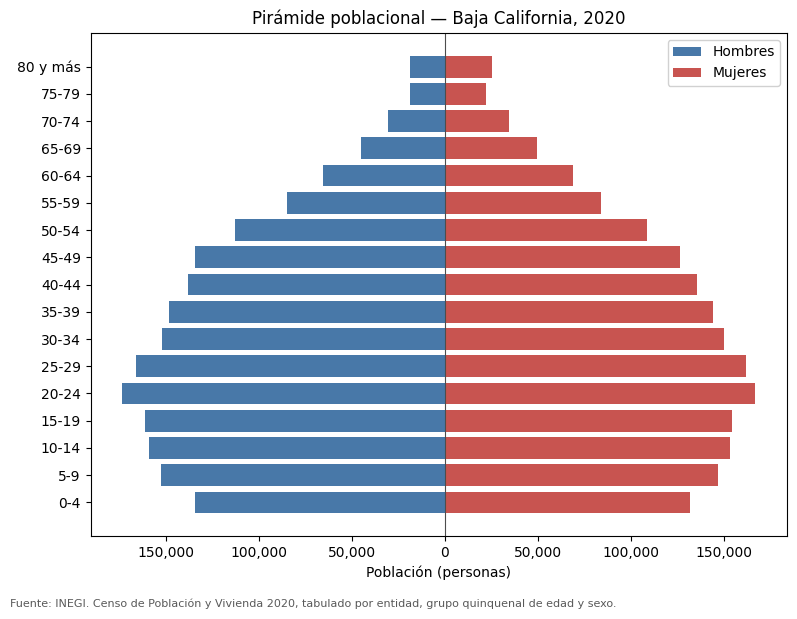

In [30]:
# TODO 5.2: construye la pirámide de tu estado (adapta el código de la Parte 3)
import matplotlib.ticker as mticker

def dibujar_piramide(ax, datos, titulo):
    ax.barh(datos['grupo'], -datos['hombres'], color='#4878a8', label='Hombres')
    ax.barh(datos['grupo'],  datos['mujeres'], color='#c85450', label='Mujeres')
    ax.axvline(0, color='0.3', lw=0.8)
    ax.set_xlabel('Población (personas)')
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{abs(int(x)):,}'))
    ax.legend(loc='upper right', framealpha=0.9)

fig, ax = plt.subplots(figsize=(8, 6))
dibujar_piramide(ax, bc2020, 'Pirámide poblacional — Baja California, 2020')
fig.text(0.01, -0.02,
         'Fuente: INEGI. Censo de Población y Vivienda 2020, tabulado por entidad, '
         'grupo quinquenal de edad y sexo.',
         fontsize=8, color='0.35')
plt.tight_layout()
plt.savefig('piramide_BC_2020.png', dpi=150, bbox_inches='tight')
plt.show()


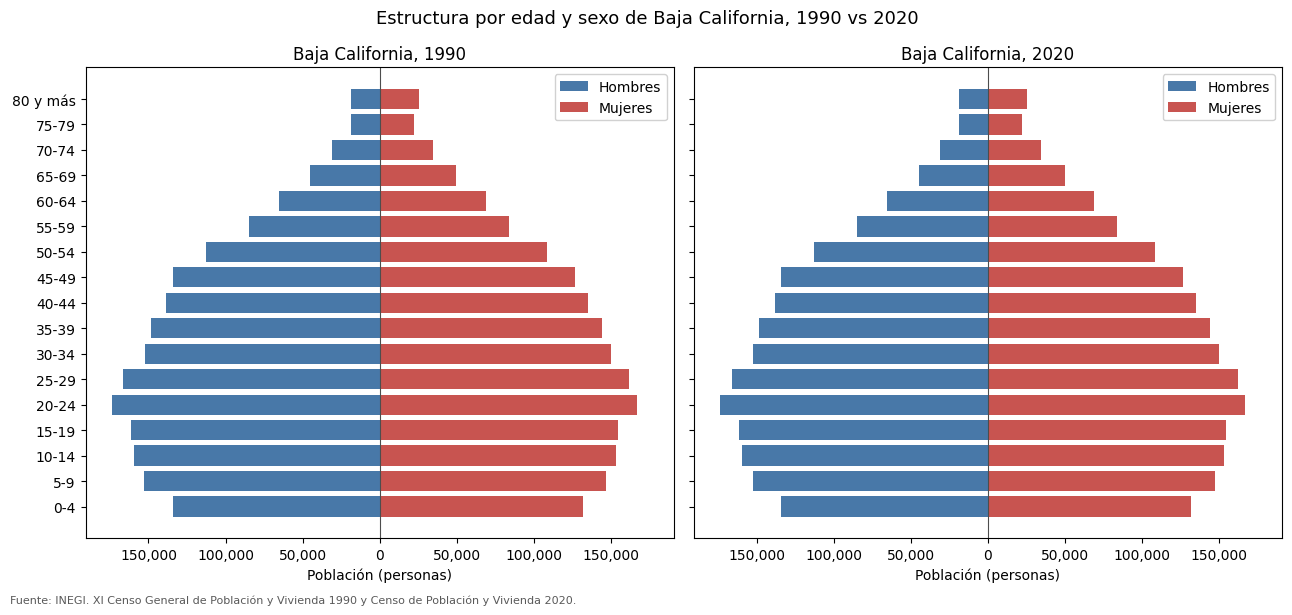

In [31]:
# TODO 5.3 (reto, opcional): grafica las pirámides de tu estado en 1990 y 2020 lado a lado.
# ¿Qué le pasó a la base? Guarda esta gráfica: es la primera figura de tu Entrega 1 (semana 7).

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

dibujar_piramide(axes[0], bc1990, 'Baja California, 1990')
dibujar_piramide(axes[1], bc2020, 'Baja California, 2020')

lim = max(bc2020['hombres'].max(), bc2020['mujeres'].max()) * 1.1
for ax in axes:
    ax.set_xlim(-lim, lim)

fig.suptitle('Estructura por edad y sexo de Baja California, 1990 vs 2020', fontsize=13)
fig.text(0.01, -0.01,
         'Fuente: INEGI. XI Censo General de Población y Vivienda 1990 y '
         'Censo de Población y Vivienda 2020.',
         fontsize=8, color='0.35')
plt.tight_layout()
plt.savefig('piramides_BC_1990_2020.png', dpi=150, bbox_inches='tight')
plt.show()


In [32]:
resumen = pd.DataFrame({
    'grupo':   bc2020['grupo'],
    '% 1990':  bc1990['total'] / bc1990['total'].sum() * 100,
    '% 2020':  bc2020['total'] / bc2020['total'].sum() * 100,
}).round(2)

def indicadores(d, etiqueta):
    tot = d['total'].sum()
    menores15 = d.loc[0:2, 'total'].sum()
    mayores65 = d[d['grupo'].isin(['65-69', '70-74', '75-79', '80 y más'])]['total'].sum()
    print(f'{etiqueta}: población {tot:>10,.0f} | 0-14 = {menores15/tot*100:4.1f} % | '
          f'65+ = {mayores65/tot*100:4.1f} % | índice de envejecimiento = '
          f'{mayores65/menores15*100:5.1f} adultos mayores por cada 100 menores de 15')

indicadores(bc1990, '1990')
indicadores(bc2020, '2020')
print()
print(resumen.to_string(index=False))

#¿Qué le pasó a la base?
#Los menores de 15 años pasaron de representar el 34.9% en 1990 a solo el 23.4% en 2020.
#Al mismo tiempo, el mayor volumen de población se desplazó hacia el centro (edades de 20 a 39 años). Dado que Baja California es un estado con
#altos niveles de inmigración, este bulto en edades productivas refleja el envejecimiento de los niños de 1990 y también la llegada
#masiva de migrantes en edad laboral de otros estados.


1990: población  3,760,801 | 0-14 = 23.4 % | 65+ =  6.5 % | índice de envejecimiento =  27.9 adultos mayores por cada 100 menores de 15
2020: población  3,760,801 | 0-14 = 23.4 % | 65+ =  6.5 % | índice de envejecimiento =  27.9 adultos mayores por cada 100 menores de 15

   grupo  % 1990  % 2020
     0-4    7.08    7.08
     5-9    7.97    7.97
   10-14    8.31    8.31
   15-19    8.39    8.39
   20-24    9.05    9.05
   25-29    8.73    8.73
   30-34    8.04    8.04
   35-39    7.77    7.77
   40-44    7.28    7.28
   45-49    6.94    6.94
   50-54    5.89    5.89
   55-59    4.48    4.48
   60-64    3.56    3.56
   65-69    2.52    2.52
   70-74    1.74    1.74
   75-79    1.09    1.09
80 y más    1.18    1.18


## Cierre y entrega

**Checklist antes de entregar:**
- [ ] Todas las celdas `TODO` resueltas y el notebook corre de arriba a abajo sin errores (Entorno de ejecución → Reiniciar y ejecutar todo).
- [ ] Valores de la Parte 4 anotados para contrastarlos en clase.
- [ ] Pirámide de tu estado con título y fuente.
- [ ] Comentarios de interpretación (2.3, 3.1, 4.3) escritos con tus palabras.

**Para la semana 2:** lectura de Preston cap. 2 y las preguntas 1–3 de la autoevaluación de las notas, trabajadas por escrito.
---

## ⚠ Cómo se entrega: el ARCHIVO, no el enlace

**No compartas el enlace de Colab.** El sistema necesita el archivo, y hay dos
razones de fondo:

1. Un enlace apunta a un notebook que **sigue siendo tuyo y sigue cambiando**.
   No hay una versión que calificar: lo que el profesor abra mañana puede no ser
   lo que entregaste hoy.
2. La retroalimentación automática necesita leer el archivo. Con un enlace no
   recibes nada.

Los tres pasos, en Colab:

1. **Archivo** → **Descargar** → **Descargar .ipynb**
2. Ve a la página de la actividad en el sistema.
3. Arrastra el `.ipynb` a la zona de subida y presiona **Entregar notebook**.

Al subirlo recibes en menos de un minuto tus puntos por sección y una
orientación para mejorarlos, y **te queda un segundo intento** para corregir.

